# Tabular Baseline - Fraud Detection (PaySim)

Logistic Regression baseline for binary transaction fraud classification.
No feature engineering is applied - raw PaySim features only - so this
notebook establishes a clean lower bound before any feature work.

## Pipeline
1. Load & validate CSV splits
2. Inspect class balance
3. Three variants: no balancing / class weights / SMOTE
4. Threshold tuning on validation set (cost-sensitive)
5. Test evaluation and comparison

In [3]:
from pathlib import Path
import json
import sys
import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from tabular_baseline_utils import (
    prepare_dataframes,
    build_preprocessor,
    build_logreg_pipeline,
    fit_model,
    evaluate_model,
    search_thresholds,
    compute_cost_table,
    evaluate_with_threshold,
    compute_expected_cost_from_cm,
    save_experiment_outputs,
)

project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"
results_root = project_root / "results"

print("Project root:", project_root)
print("Processed dir:", processed_dir)
print("Results root:", results_root)

Project root: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis
Processed dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed
Results root: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results


In [4]:
import random
import numpy as np

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

SEED = 42
set_seed(SEED)
print(f"Random seed: {SEED}")

Random seed: 42


# Tabular full baseline



In [5]:
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test = pd.read_csv(processed_dir / "paysim_test.csv")

data = prepare_dataframes(paysim_train, paysim_val, paysim_test)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

categorical_features = data["categorical_features"]
numeric_features = data["numeric_features"]
feature_cols = data["feature_cols"]

print("Features used:", feature_cols)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("\nTrain class counts:")
print(y_train.value_counts())

Features used: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']
X_train shape: (4453834, 8)
X_val shape: (636262, 8)
X_test shape: (1272524, 8)

Train class counts:
isFraud
0    4448085
1       5749
Name: count, dtype: int64


In [6]:
preprocessor = build_preprocessor(numeric_features, categorical_features)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['step', 'amount', 'oldbalanceOrg',
                                  'newbalanceOrig', 'oldbalanceDest',
                                  'newbalanceDest', 'isFlaggedFraud']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['type'])])

## 1. Logistic Regression without imbalance handling

This version uses the original PaySim split and trains Logistic Regression without any balancing method.

In [7]:
import joblib

results_dir = results_root / "tabular_full_baseline_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_path = results_dir / "none_model.joblib"

FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR-none model...")
    model_none = joblib.load(model_path)
    print("Model loaded successfully.")

else:
    print("Saved model not found. Training LR-none model...")

    model_none = build_logreg_pipeline(
        preprocessor=preprocessor,
        imbalance_method="none",
    )

    model_none = fit_model(model_none, X_train, y_train)

    joblib.dump(model_none, model_path)

    print("Training finished and model saved to:", model_path)

Checking model path:
c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_none\none_model.joblib
Model exists: True
Already trained. Loading saved LR-none model...
Model loaded successfully.


In [9]:
val_metrics_none, val_cm_none = evaluate_model(model_none, X_val, y_val, split_name="validation_none")
test_metrics_none, test_cm_none = evaluate_model(model_none, X_test, y_test, split_name="test_none")



=== VALIDATION_NONE ===
accuracy: 0.998982
precision: 0.994286
recall: 0.211937
f1: 0.349398
roc_auc: 0.946992
pr_auc: 0.449465

Confusion matrix:
[[635440      1]
 [   647    174]]

Classification report:
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995    635441
           1     0.9943    0.2119    0.3494       821

    accuracy                         0.9990    636262
   macro avg     0.9966    0.6060    0.6744    636262
weighted avg     0.9990    0.9990    0.9987    636262


=== TEST_NONE ===
accuracy: 0.998988
precision: 0.997199
recall: 0.216677
f1: 0.356000
roc_auc: 0.952047
pr_auc: 0.454219

Confusion matrix:
[[1270880       1]
 [   1287     356]]

Classification report:
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995   1270881
           1     0.9972    0.2167    0.3560      1643

    accuracy                         0.9990   1272524
   macro avg     0.9981    0.6083    0.6777

### Interpretation of the Tabular Full Baseline

The baseline model shows the accuracy paradox very clearly. Although the model achieves almost 99.9% accuracy, this result is not very informative because the dataset is extremely imbalanced. Fraudulent transactions represent only around 0.13% of all observations. This means that even a naive model that predicts every transaction as legitimate would achieve approximately 99.87% accuracy. Therefore, accuracy is not a suitable main metric for this task. Instead, F1-score, ROC-AUC, and especially PR-AUC are more useful for evaluating fraud detection performance.

The model achieves almost perfect precision but very low recall. On the test set, precision is 0.9972, which means that almost every transaction predicted as fraud is truly fraudulent. However, recall is only 0.2167, meaning that the model detects only around 21.7% of all fraud cases. In practical terms, it misses 1,287 out of 1,643 fraudulent transactions. This shows that the model is extremely conservative: it almost never raises a false alarm, but it also fails to detect most fraud cases.

The difference between ROC-AUC and PR-AUC is also important. The ROC-AUC score of 0.9520 suggests that the model has strong ranking ability and can separate fraud from legitimate transactions reasonably well. However, the PR-AUC score of 0.4542 gives a more realistic view of minority-class performance. In highly imbalanced datasets, ROC-AUC can look overly optimistic because the false positive rate remains very low when there are many negative cases. PR-AUC focuses on the precision-recall trade-off for the positive class, so it is more informative for fraud detection. For this reason, PR-AUC is treated as the primary ranking metric in the tabular experiments.

Overall, this baseline shows that Logistic Regression without imbalance correction cannot reliably detect fraud. The model is very precise when it predicts fraud, but it misses the majority of fraudulent transactions. The next variants, such as class weighting and SMOTE, are therefore needed to improve recall. However, this improvement will probably come with lower precision and more false positives.

In [11]:
threshold_results_none = search_thresholds(model_none, X_val, y_val)
print(threshold_results_none)

    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.931034  0.328867  0.486049              290
1        0.15   0.976096  0.298417  0.457090              251
2        0.20   0.987179  0.281364  0.437915              234
3        0.25   0.990868  0.264312  0.417308              219
4        0.30   0.990244  0.247259  0.395712              205
5        0.35   0.994872  0.236297  0.381890              195
6        0.40   0.994737  0.230207  0.373887              190
7        0.45   0.994536  0.221681  0.362550              183
8        0.50   0.994286  0.211937  0.349398              175
9        0.55   0.994186  0.208283  0.344411              172
10       0.60   0.994118  0.205847  0.341070              170
11       0.65   0.993976  0.200974  0.334347              166
12       0.70   0.993631  0.190012  0.319018              157
13       0.75   0.993506  0.186358  0.313846              154
14       0.80   1.000000  0.181486  0.307216              149
15      

In [12]:
cost_df_none = compute_cost_table(threshold_results_none, y_val)
print(cost_df_none.head())

   threshold   tp  fp   fn      tn  precision    recall        f1  \
0       0.10  270  20  551  635421   0.931034  0.328867  0.486049   
1       0.15  245   6  576  635435   0.976096  0.298417  0.457090   
2       0.20  231   3  590  635438   0.987179  0.281364  0.437915   
3       0.25  217   2  604  635439   0.990868  0.264312  0.417308   
4       0.30  203   2  618  635439   0.990244  0.247259  0.395712   

   predicted_fraud  expected_cost  
0              290       27560000  
1              251       28803000  
2              234       29501500  
3              219       30201000  
4              205       30901000  


### Threshold tuning for the LR-none baseline

Threshold tuning was performed on the validation set. The purpose was to find a decision threshold that gives the lowest expected cost. By default, Logistic Regression uses a threshold of 0.50. In this experiment, lower thresholds were tested to make the model more sensitive to fraud cases.

The best threshold was 0.10, because it produced the lowest expected cost on the validation set: $27,560,000. At this threshold, the model detected 270 fraud cases, missed 551 fraud cases, and produced 20 false positives. This means that lowering the threshold made the model more aggressive. It predicted fraud more often, which increased recall but also created more false alarms.

At threshold 0.10, precision remained high at 0.9310. This means that most transactions predicted as fraud were actually fraudulent. Recall increased to 0.3289, meaning that the model detected around 32.9% of fraud cases. This is better than the default threshold, but the model still missed most fraud cases.

As the threshold increased from 0.10 to 0.30, the model became more conservative. Precision increased slightly, but recall decreased. For example, at threshold 0.30, precision was 0.9902, but recall dropped to 0.2473. This means that the model made fewer false positive errors, but missed more fraud cases.



In [16]:
default_validation_cost = val_cost_none["expected_cost"]
best_validation_cost = cost_df_none.iloc[0]["expected_cost"]

cost_reduction = default_validation_cost - best_validation_cost

print(f"Default validation cost: ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction: ${cost_reduction:,.0f}")

Default validation cost: $32,350,500
Best tuned validation cost: $27,560,000
Cost reduction: $4,790,500


The expected cost increased as the threshold became higher. This happens because false negatives are much more expensive than false positives. In this experiment, missing one fraud case costs $50,000, while one false alarm costs only $500. Therefore, accepting some additional false positives is reasonable if it helps reduce the number of missed fraud cases.

At threshold 0.10, the expected validation cost was calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 551 × $50,000 + 20 × $500  
Expected cost = $27,550,000 + $10,000  
Expected cost = $27,560,000

For comparison, the default validation cost was:

Default validation cost = 647 × $50,000 + 1 × $500  
Default validation cost = $32,350,000 + $500  
Default validation cost = $32,350,500

Therefore, threshold tuning reduced the validation cost by:

Cost reduction = $32,350,500 - $27,560,000  
Cost reduction = $4,790,500

Thus, threshold 0.10 was selected as the tuned threshold for the LR-none model. It gave the best cost-sensitive trade-off among the tested thresholds.

Threshold tuning helps the unbalanced Logistic Regression model by increasing recall and reducing expected cost. However, even at the best threshold, the model still detects only about one third of fraud cases. This means that threshold tuning alone is not enough, and imbalance correction is still needed.

In [14]:
best_threshold_none = float(cost_df_none.iloc[0]["threshold"])
best_threshold_none

0.1

In [15]:
tuned_metrics_none, tuned_cm_none = evaluate_with_threshold(model_none, X_test, y_test, best_threshold_none)
cost_summary_none = compute_expected_cost_from_cm(tuned_cm_none)

print(cost_summary_none)


Tuned threshold: 0.1
Precision: 0.956140350877193
Recall: 0.3317102860620816
F1: 0.49254405784003613

Confusion matrix:
[[1270856      25]
 [   1098     545]]

Classification report:
              precision    recall  f1-score   support

           0     0.9991    1.0000    0.9996   1270881
           1     0.9561    0.3317    0.4925      1643

    accuracy                         0.9991   1272524
   macro avg     0.9776    0.6658    0.7461   1272524
weighted avg     0.9991    0.9991    0.9989   1272524

{'tp': 545, 'fp': 25, 'fn': 1098, 'tn': 1270856, 'expected_cost': 54912500}


### Tuned threshold results for the LR-none baseline

After selecting the threshold on the validation set, the same threshold of 0.10 was applied to the test set. This gives the final tuned performance of the LR-none baseline.

On the test set, the tuned model achieved a precision of 0.9561, recall of 0.3317, and F1-score of 0.4925. This means that when the model predicted fraud, it was correct around 95.6% of the time. However, it still detected only around 33.2% of all actual fraud cases.

The confusion matrix shows this trade-off clearly. The model correctly detected 545 fraud cases, but it still missed 1,098 fraud cases. It also produced 25 false positives, meaning that 25 legitimate transactions were incorrectly flagged as fraud.

Compared with the default threshold, the tuned threshold improved recall and F1-score. The number of detected fraud cases increased from 356 to 545, so the model caught 189 additional fraud cases. However, false positives increased from 1 to 25. This is still a reasonable trade-off because false negatives are much more expensive than false positives.

The expected test cost was calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 1,098 × $50,000 + 25 × $500  
Expected cost = $54,900,000 + $12,500  
Expected cost = $54,912,500

This is lower than the default test cost of $64,350,500. Therefore, threshold tuning reduced the expected test cost by:

Cost reduction = $64,350,500 - $54,912,500  
Cost reduction = $9,438,000

Overall, threshold tuning improved the LR-none baseline. It increased recall, improved the F1-score, detected more fraud cases, and reduced the expected cost. However, the model still missed 1,098 out of 1,643 fraud cases, which means that around two thirds of fraud cases remained undetected. This shows that threshold tuning helps, but it does not fully solve the class imbalance problem.

In [17]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_none,
    val_metrics=val_metrics_none,
    test_metrics=test_metrics_none,
    val_cm=val_cm_none,
    test_cm=test_cm_none,
    threshold_results=threshold_results_none,
    cost_df=cost_df_none,
    tuned_metrics=tuned_metrics_none,
    tuned_cm=tuned_cm_none,
    prefix="none",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_none


In [18]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['none_cost_results.csv',
 'none_metrics_summary.csv',
 'none_model.joblib',
 'none_test_confusion_matrix.csv',
 'none_test_metrics.json',
 'none_threshold_results.csv',
 'none_tuned_test_confusion_matrix.csv',
 'none_tuned_test_metrics.json',
 'none_validation_confusion_matrix.csv',
 'none_validation_metrics.json']

## 2. Logistic Regression with class weights

This version uses the same features and split, but applies `class_weight="balanced"` during training.

In [17]:
import joblib

results_dir = results_root / "tabular_full_baseline_class_weight"
results_dir.mkdir(parents=True, exist_ok=True)

model_path = results_dir / "class_weight_model.joblib"

FORCE_RETRAIN = False

print("Results dir:", results_dir)
print("Model path:", model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR class_weight model...")
    model_weighted = joblib.load(model_path)
    print("Model loaded.")

else:
    print("Saved model not found. Training LR class_weight model...")

    preprocessor = build_preprocessor(numeric_features, categorical_features)

    model_weighted = build_logreg_pipeline(
        preprocessor=preprocessor,
        imbalance_method="class_weight",
    )

    model_weighted = fit_model(model_weighted, X_train, y_train)

    joblib.dump(model_weighted, model_path)

    print("Training finished and model saved.")

Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_class_weight
Model path: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_class_weight\class_weight_model.joblib
Model exists: True
Already trained. Loading saved LR class_weight model...
Model loaded.


In [18]:
val_metrics_weighted, val_cm_weighted = evaluate_model(
    model_weighted, X_val, y_val, split_name="validation_class_weight"
)

test_metrics_weighted, test_cm_weighted = evaluate_model(
    model_weighted, X_test, y_test, split_name="test_class_weight"
)


=== VALIDATION_CLASS_WEIGHT ===
accuracy: 0.949467
precision: 0.023888
recall: 0.957369
f1: 0.046614
roc_auc: 0.991780
pr_auc: 0.599905

Confusion matrix:
[[603324  32117]
 [    35    786]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9495    0.9740    635441
           1     0.0239    0.9574    0.0466       821

    accuracy                         0.9495    636262
   macro avg     0.5119    0.9534    0.5103    636262
weighted avg     0.9987    0.9495    0.9728    636262


=== TEST_CLASS_WEIGHT ===
accuracy: 0.949581
precision: 0.024188
recall: 0.967133
f1: 0.047195
roc_auc: 0.992945
pr_auc: 0.601748

Confusion matrix:
[[1206775   64106]
 [     54    1589]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9496    0.9741   1270881
           1     0.0242    0.9671    0.0472      1643

    accuracy                         0.9496   1272524
   macro avg     0.5121    

### Interpretation of the LR class_weight baseline

The Logistic Regression model with class weighting behaves very differently from the LR-none baseline. By using `class_weight="balanced"`, the model gives more importance to the minority class during training. As a result, it becomes much more sensitive to fraud cases.

The main improvement is recall. On the validation set, recall increases to 0.9574, and on the test set, recall reaches 0.9671. This means that the model detects almost all fraudulent transactions. On the test set, it correctly identifies 1,589 out of 1,643 fraud cases and misses only 54.

However, this improvement comes with a very large drop in precision. On the test set, precision is only 0.0242. This means that only about 2.4% of the transactions predicted as fraud are actually fraudulent. In practical terms, the model produces 64,106 false positives on the test set. Therefore, the model catches most fraud cases, but it also incorrectly flags many legitimate transactions.

The F1-score remains very low, with 0.0466 on validation and 0.0472 on test. This happens because precision is extremely low, even though recall is very high. The model is now recall-oriented, but not precise.

The ROC-AUC and PR-AUC scores are stronger than in the LR-none baseline. On the test set, ROC-AUC increases to 0.9929, and PR-AUC increases to 0.6017. This suggests that class weighting improves the model’s ranking ability and helps it separate fraud from legitimate transactions better than the unweighted baseline.

Overall, the class-weighted Logistic Regression model solves one problem but creates another. It greatly reduces the number of missed fraud cases, which is important in fraud detection. However, it produces a very large number of false positives. This means that the model is much better at detecting fraud, but it may create too many false alarms at the default threshold.

### Threshold tuning for the LR class_weight model

In [19]:
threshold_results_weighted = search_thresholds(model_weighted, X_val, y_val)
print(threshold_results_weighted.head())

   threshold  precision    recall        f1  predicted_fraud
0       0.10   0.004923  1.000000  0.009798           166762
1       0.15   0.005787  1.000000  0.011507           141875
2       0.20   0.006797  1.000000  0.013503           120784
3       0.25   0.008034  1.000000  0.015941           102187
4       0.30   0.009624  0.997564  0.019063            85103


Threshold tuning was also applied to the class-weighted Logistic Regression model. Unlike the LR-none baseline, this model is already very sensitive to fraud because class weighting gives more importance to the minority class during training. Therefore, low thresholds such as 0.10, 0.15, and 0.20 make the model too aggressive.

At threshold 0.10, the model reaches perfect recall on the validation set, meaning that it detects all fraud cases. However, it predicts 166,762 transactions as fraud. This creates a very large number of false positives and makes precision extremely low. Therefore, very low thresholds are not practical for this model.

The cost-based threshold search shows that the best threshold is 0.75. At this threshold, the model detects 681 fraud cases, misses 140 fraud cases, and produces 7,852 false positives on the validation set. This gives the lowest expected validation cost of $10,926,000.

At threshold 0.75, recall is 0.8295 and precision is 0.0798. This means that the model still detects around 83% of fraud cases, while reducing the number of false positives compared with lower thresholds. Although precision remains low, this threshold provides the best balance under the assumed cost structure.

In [20]:
cost_df_weighted = compute_cost_table(threshold_results_weighted, y_val)
print(cost_df_weighted.head())

   threshold   tp     fp   fn      tn  precision    recall        f1  \
0       0.75  681   7852  140  627589   0.079808  0.829476  0.145606   
1       0.70  707  10910  114  624531   0.060859  0.861145  0.113684   
2       0.80  647   5309  174  630132   0.108630  0.788063  0.190940   
3       0.65  730  14451   91  620990   0.048086  0.889160  0.091239   
4       0.85  616   3130  205  632311   0.164442  0.750305  0.269761   

   predicted_fraud  expected_cost  
0             8533       10926000  
1            11617       11155000  
2             5956       11354500  
3            15181       11775500  
4             3746       11815000  


The expected validation cost at threshold 0.75 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 140 × $50,000 + 7,852 × $500  
Expected cost = $7,000,000 + $3,926,000  
Expected cost = $10,926,000

Compared with the default threshold, threshold tuning makes the class-weighted model less aggressive and reduces the number of false positives. Therefore, for the class-weighted model, threshold tuning is used not to increase recall, but to control false alarms while keeping recall high.

In [26]:
best_threshold_weighted = float(cost_df_weighted.iloc[0]["threshold"])
best_threshold_weighted

0.7500000000000002

For LR-none, threshold tuning lowered the threshold from 0.50 to 0.10 to make the model more sensitive.

For LR class_weight, threshold tuning increased the threshold to 0.75 to make the model less aggressive and reduce false positives.

### Tuned threshold results for the LR class_weight model

In [28]:
tuned_metrics_weighted, tuned_cm_weighted = evaluate_with_threshold(
    model_weighted, X_test, y_test, best_threshold_weighted
)

cost_summary_weighted = compute_expected_cost_from_cm(tuned_cm_weighted)
print(cost_summary_weighted)


Tuned threshold: 0.7500000000000002
Precision: 0.08368719037508847
Recall: 0.8636640292148509
F1: 0.15258884886284207

Confusion matrix:
[[1255344   15537]
 [    224    1419]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9878    0.9938   1270881
           1     0.0837    0.8637    0.1526      1643

    accuracy                         0.9876   1272524
   macro avg     0.5418    0.9257    0.5732   1272524
weighted avg     0.9986    0.9876    0.9927   1272524

{'tp': 1419, 'fp': 15537, 'fn': 224, 'tn': 1255344, 'expected_cost': 18968500}


After threshold tuning, the selected threshold for the class-weighted Logistic Regression model was 0.75. This is higher than the default threshold of 0.50. This makes sense because the class-weighted model is already very aggressive in predicting fraud. Increasing the threshold helps reduce the number of false positives while keeping recall high.

On the test set, the tuned class-weighted model achieved a precision of 0.0837, recall of 0.8637, and F1-score of 0.1526. This means that the model detects around 86.4% of all fraud cases, but only around 8.4% of the transactions predicted as fraud are actually fraudulent.

The confusion matrix shows this trade-off clearly. The model correctly detects 1,419 fraud cases and misses 224 fraud cases. It also produces 15,537 false positives, meaning that many legitimate transactions are incorrectly flagged as fraud.

Compared with the default threshold, threshold tuning makes the class-weighted model less aggressive. At the default threshold, the model detected 1,589 fraud cases but produced 64,106 false positives. After tuning, the number of false positives drops from 64,106 to 15,537, while the number of missed fraud cases increases from 54 to 224. This is a better cost-sensitive trade-off because the large reduction in false positives lowers the total expected cost.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 224 × $50,000 + 15,537 × $500  
Expected cost = $11,200,000 + $7,768,500  
Expected cost = $18,968,500

This is much lower than the default LR-none baseline cost of $64,350,500 and also lower than the tuned LR-none cost of $54,912,500. Therefore, class weighting substantially improves the model from a cost-sensitive perspective.

Overall, the tuned class-weighted model is much better at detecting fraud than the LR-none model. It misses far fewer fraud cases, which greatly reduces the expected cost. However, precision remains low because the model still creates many false positives. This shows that class weighting improves recall and cost performance, but it does not fully solve the precision problem.

In [26]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_weighted,
    val_metrics=val_metrics_weighted,
    test_metrics=test_metrics_weighted,
    val_cm=val_cm_weighted,
    test_cm=test_cm_weighted,
    threshold_results=threshold_results_weighted,
    cost_df=cost_df_weighted,
    tuned_metrics=tuned_metrics_weighted,
    tuned_cm=tuned_cm_weighted,
    prefix="class_weight",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_class_weight


In [27]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['class_weight_cost_results.csv',
 'class_weight_metrics_summary.csv',
 'class_weight_model.joblib',
 'class_weight_test_confusion_matrix.csv',
 'class_weight_test_metrics.json',
 'class_weight_threshold_results.csv',
 'class_weight_tuned_test_confusion_matrix.csv',
 'class_weight_tuned_test_metrics.json',
 'class_weight_validation_confusion_matrix.csv',
 'class_weight_validation_metrics.json']

## 3. Logistic Regression with SMOTE

This version uses the same features and split, but applies SMOTE only on the training data.

In [21]:
import joblib

results_dir = results_root / "tabular_full_baseline_smote"
results_dir.mkdir(parents=True, exist_ok=True)

model_path = results_dir / "smote_model.joblib"

FORCE_RETRAIN = False

print("Results dir:", results_dir)
print("Model path:", model_path)
print("Model exists:", model_path.exists())

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved LR-SMOTE model...")
    model_smote = joblib.load(model_path)
    print("Model loaded.")

else:
    print("Saved model not found. Training LR-SMOTE model...")

    preprocessor = build_preprocessor(numeric_features, categorical_features)

    model_smote = build_logreg_pipeline(
        preprocessor=preprocessor,
        imbalance_method="smote",
    )

    model_smote = fit_model(model_smote, X_train, y_train)

    joblib.dump(model_smote, model_path)

    print("Training finished and model saved.")

Results dir: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_smote
Model path: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_smote\smote_model.joblib
Model exists: True
Already trained. Loading saved LR-SMOTE model...
Model loaded.


In [22]:
val_metrics_smote, val_cm_smote = evaluate_model(
    model_smote, X_val, y_val, split_name="validation_smote"
)

test_metrics_smote, test_cm_smote = evaluate_model(
    model_smote, X_test, y_test, split_name="test_smote"
)


=== VALIDATION_SMOTE ===
accuracy: 0.950871
precision: 0.024733
recall: 0.964677
f1: 0.048229
roc_auc: 0.993306
pr_auc: 0.619049

Confusion matrix:
[[604211  31230]
 [    29    792]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9509    0.9748    635441
           1     0.0247    0.9647    0.0482       821

    accuracy                         0.9509    636262
   macro avg     0.5123    0.9578    0.5115    636262
weighted avg     0.9987    0.9509    0.9736    636262


=== TEST_SMOTE ===
accuracy: 0.951280
precision: 0.025115
recall: 0.971394
f1: 0.048965
roc_auc: 0.994149
pr_auc: 0.619863

Confusion matrix:
[[1208930   61951]
 [     47    1596]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9513    0.9750   1270881
           1     0.0251    0.9714    0.0490      1643

    accuracy                         0.9513   1272524
   macro avg     0.5125    0.9613    0.51

### Interpretation of the LR-SMOTE baseline

The Logistic Regression model with SMOTE behaves very differently from the LR-none baseline. SMOTE balances the training data by creating synthetic examples of the minority class. As a result, the model becomes much more sensitive to fraud cases.

The main improvement is recall. On the validation set, recall is 0.9647, and on the test set, recall reaches 0.9714. This means that the model detects almost all fraudulent transactions. On the test set, it correctly identifies 1,596 out of 1,643 fraud cases and misses only 47.

However, this improvement comes with very low precision. On the test set, precision is only 0.0251. This means that only about 2.5% of the transactions predicted as fraud are actually fraudulent. In practical terms, the model produces 61,951 false positives on the test set. Therefore, the model is very good at catching fraud, but it also incorrectly flags many legitimate transactions.

The F1-score remains low, with 0.0482 on validation and 0.0490 on test. This happens because precision is extremely low, even though recall is very high. The model is strongly recall-oriented, but not precise.

The ranking metrics are strong. On the test set, ROC-AUC is 0.9941 and PR-AUC is 0.6199. These are higher than the LR-none baseline and also slightly higher than the class-weighted model. This suggests that SMOTE improves the model’s ability to separate fraudulent and legitimate transactions.

Overall, SMOTE greatly improves fraud detection recall compared with the unbalanced baseline. The model misses very few fraud cases, which is important in fraud detection. However, the default threshold produces too many false positives. Therefore, threshold tuning is needed to reduce false alarms while keeping recall high.

### Threshold tuning for the LR-SMOTE model

In [23]:
threshold_results_smote = search_thresholds(model_smote, X_val, y_val)
print(threshold_results_smote.head())

   threshold  precision    recall        f1  predicted_fraud
0       0.10   0.006164  1.000000  0.012253           133190
1       0.15   0.007244  1.000000  0.014385           113328
2       0.20   0.008436  1.000000  0.016731            97323
3       0.25   0.009796  0.998782  0.019402            83705
4       0.30   0.011439  0.997564  0.022619            71595


In [24]:
cost_df_smote = compute_cost_table(threshold_results_smote, y_val)
print(cost_df_smote.head())

   threshold   tp     fp   fn      tn  precision    recall        f1  \
0       0.75  702   8619  119  626822   0.075314  0.855055  0.138434   
1       0.80  676   6027  145  629414   0.100850  0.823386  0.179692   
2       0.70  727  11488   94  623953   0.059517  0.885505  0.111537   
3       0.85  646   3810  175  631631   0.144973  0.786845  0.244836   
4       0.65  746  14877   75  620564   0.047750  0.908648  0.090732   

   predicted_fraud  expected_cost  
0             9321       10259500  
1             6703       10263500  
2            12215       10444000  
3             4456       10655000  
4            15623       11188500  



Threshold tuning was also applied to the LR-SMOTE model. Since SMOTE makes the model much more sensitive to fraud, low thresholds produce too many false positives. Therefore, the best threshold is higher than the default threshold.

The cost table shows that the best threshold is 0.75. At this threshold, the model detects 702 fraud cases, misses 119 fraud cases, and produces 8,619 false positives on the validation set. This gives the lowest expected validation cost of $10,259,500.

At threshold 0.75, recall is 0.8551 and precision is 0.0753. This means that the model detects around 85.5% of fraud cases, but only around 7.5% of predicted fraud cases are actually fraud. Although precision is still low, this threshold gives the best cost-sensitive balance between missed fraud and false alarms.

The expected validation cost at threshold 0.75 is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 119 × $50,000 + 8,619 × $500  
Expected cost = $5,950,000 + $4,309,500  
Expected cost = $10,259,500

The second-best threshold is 0.80, with a very similar expected cost of $10,263,500. However, threshold 0.75 is slightly better because it gives the lowest cost. It also keeps recall higher than threshold 0.80.

Overall, threshold tuning improves the LR-SMOTE model by reducing false positives while keeping recall high. Like the class-weighted model, SMOTE is very aggressive at lower thresholds, so increasing the threshold helps create a better cost-sensitive trade-off.

In [30]:
best_threshold_smote = float(cost_df_smote.iloc[0]["threshold"])
best_threshold_smote

0.7500000000000002

### Tuned threshold results for the LR-SMOTE model

In [31]:
tuned_metrics_smote, tuned_cm_smote = evaluate_with_threshold(
    model_smote, X_test, y_test, best_threshold_smote
)

cost_summary_smote = compute_expected_cost_from_cm(tuned_cm_smote)
print(cost_summary_smote)


Tuned threshold: 0.7500000000000002
Precision: 0.07961122638418697
Recall: 0.887401095556908
F1: 0.14611414541263718

Confusion matrix:
[[1254025   16856]
 [    185    1458]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9867    0.9933   1270881
           1     0.0796    0.8874    0.1461      1643

    accuracy                         0.9866   1272524
   macro avg     0.5397    0.9371    0.5697   1272524
weighted avg     0.9987    0.9866    0.9922   1272524

{'tp': 1458, 'fp': 16856, 'fn': 185, 'tn': 1254025, 'expected_cost': 17678000}



After threshold tuning, the selected threshold for the LR-SMOTE model was 0.75. This is higher than the default threshold of 0.50 because the SMOTE model is already very sensitive to fraud. Increasing the threshold helps reduce false positives while keeping recall high.

On the test set, the tuned SMOTE model achieved a precision of 0.0796, recall of 0.8874, and F1-score of 0.1461. This means that the model detects around 88.7% of all fraud cases, but only around 8.0% of the transactions predicted as fraud are actually fraudulent.

The confusion matrix shows this trade-off clearly. The model correctly detects 1,458 fraud cases and misses 185 fraud cases. It also produces 16,856 false positives, meaning that many legitimate transactions are incorrectly flagged as fraud.

Compared with the default threshold, threshold tuning makes the SMOTE model less aggressive. At the default threshold, the model detected 1,596 fraud cases but produced 61,951 false positives. After tuning, false positives decrease from 61,951 to 16,856, while missed fraud cases increase from 47 to 185. This is a better cost-sensitive trade-off because the large reduction in false positives lowers the total expected cost.

The expected test cost is calculated as:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 185 × $50,000 + 16,856 × $500  
Expected cost = $9,250,000 + $8,428,000  
Expected cost = $17,678,000

This is the lowest expected cost among the three Logistic Regression variants. It is lower than the tuned LR-none cost of $54,912,500 and slightly lower than the tuned class-weighted cost of $18,968,500.

Overall, the tuned SMOTE model gives the best cost-sensitive result among the Logistic Regression models. It detects most fraud cases and produces the lowest expected cost. However, precision remains low, so the model still generates many false positives.

In [35]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_smote,
    val_metrics=val_metrics_smote,
    test_metrics=test_metrics_smote,
    val_cm=val_cm_smote,
    test_cm=test_cm_smote,
    threshold_results=threshold_results_smote,
    cost_df=cost_df_smote,
    tuned_metrics=tuned_metrics_smote,
    tuned_cm=tuned_cm_smote,
    prefix="smote",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_baseline_smote


In [36]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['smote_cost_results.csv',
 'smote_metrics_summary.csv',
 'smote_model.joblib',
 'smote_test_confusion_matrix.csv',
 'smote_test_metrics.json',
 'smote_threshold_results.csv',
 'smote_tuned_test_confusion_matrix.csv',
 'smote_tuned_test_metrics.json',
 'smote_validation_confusion_matrix.csv',
 'smote_validation_metrics.json']

## 4. Comparison of imbalance-handling methods

The table below compares the results of the three Logistic Regression versions:
- no balancing
- class weights
- SMOTE

In [33]:
comparison_df = pd.DataFrame([
    {
        "model": "none",
        "val_f1": val_metrics_none["f1"],
        "val_roc_auc": val_metrics_none["roc_auc"],
        "val_pr_auc": val_metrics_none["pr_auc"],
        "test_f1": test_metrics_none["f1"],
        "test_roc_auc": test_metrics_none["roc_auc"],
        "test_pr_auc": test_metrics_none["pr_auc"],
        "best_threshold": best_threshold_none,
        "tuned_test_precision": tuned_metrics_none["precision"],
        "tuned_test_recall": tuned_metrics_none["recall"],
        "tuned_test_f1": tuned_metrics_none["f1"],
        "tuned_expected_cost": cost_summary_none["expected_cost"],
    },
    {
        "model": "class_weight",
        "val_f1": val_metrics_weighted["f1"],
        "val_roc_auc": val_metrics_weighted["roc_auc"],
        "val_pr_auc": val_metrics_weighted["pr_auc"],
        "test_f1": test_metrics_weighted["f1"],
        "test_roc_auc": test_metrics_weighted["roc_auc"],
        "test_pr_auc": test_metrics_weighted["pr_auc"],
        "best_threshold": best_threshold_weighted,
        "tuned_test_precision": tuned_metrics_weighted["precision"],
        "tuned_test_recall": tuned_metrics_weighted["recall"],
        "tuned_test_f1": tuned_metrics_weighted["f1"],
        "tuned_expected_cost": cost_summary_weighted["expected_cost"],
    },
    {
        "model": "smote",
        "val_f1": val_metrics_smote["f1"],
        "val_roc_auc": val_metrics_smote["roc_auc"],
        "val_pr_auc": val_metrics_smote["pr_auc"],
        "test_f1": test_metrics_smote["f1"],
        "test_roc_auc": test_metrics_smote["roc_auc"],
        "test_pr_auc": test_metrics_smote["pr_auc"],
        "best_threshold": best_threshold_smote,
        "tuned_test_precision": tuned_metrics_smote["precision"],
        "tuned_test_recall": tuned_metrics_smote["recall"],
        "tuned_test_f1": tuned_metrics_smote["f1"],
        "tuned_expected_cost": cost_summary_smote["expected_cost"],
    },
])

print(comparison_df)

          model    val_f1  val_roc_auc  val_pr_auc   test_f1  test_roc_auc  \
0          none  0.349398     0.946992    0.449465  0.356000      0.952047   
1  class_weight  0.046614     0.991780    0.599905  0.047195      0.992945   
2         smote  0.048229     0.993306    0.619049  0.048965      0.994149   

   test_pr_auc  best_threshold  tuned_test_precision  tuned_test_recall  \
0     0.454219            0.10              0.956140           0.331710   
1     0.601748            0.75              0.083687           0.863664   
2     0.619863            0.75              0.079611           0.887401   

   tuned_test_f1  tuned_expected_cost  
0       0.492544             54912500  
1       0.152589             18968500  
2       0.146114             17678000  


In [37]:
comparison_df.sort_values("tuned_expected_cost")[
    [
        "model",
        "best_threshold",
        "tuned_test_precision",
        "tuned_test_recall",
        "tuned_test_f1",
        "tuned_expected_cost"
    ]
]

,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
2,smote,0.75,0.079611,0.887401,0.146114,17678000
1,class_weight,0.75,0.083687,0.863664,0.152589,18968500
0,none,0.10,0.956140,0.331710,0.492544,54912500


The comparison shows a clear trade-off between the three Logistic Regression variants.

The LR-none model has the highest default F1-score and the highest tuned F1-score. However, this is mainly because it has very high precision. It produces very few false positives, but its recall is low, so it misses many fraud cases. After threshold tuning, its recall is only 0.3317 and its expected cost remains high at $54,912,500.

The class-weighted and SMOTE models behave differently. They have lower F1-scores because they produce more false positives, but they detect many more fraud cases. After threshold tuning, class weighting reaches a recall of 0.8637, while SMOTE reaches the highest recall of 0.8874.

The ranking metrics also improve with imbalance correction. Test PR-AUC increases from 0.4542 for LR-none to 0.6017 for class weighting and 0.6199 for SMOTE. This shows that imbalance-aware methods improve the model’s ability to rank fraud cases higher than legitimate transactions.

From a cost-sensitive perspective, SMOTE is the best Logistic Regression variant. It achieves the lowest expected cost of $17,678,000, followed by class weighting with $18,968,500. Therefore, although LR-none has the highest F1-score, SMOTE is preferred because it detects more fraud cases and reduces the expected cost the most.

## Class imbalance plot


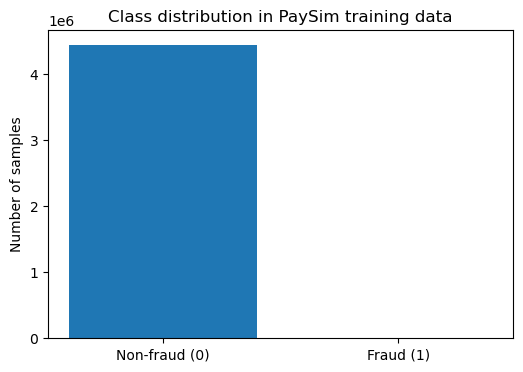

In [34]:
import matplotlib.pyplot as plt

class_counts = y_train.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Non-fraud (0)", "Fraud (1)"], class_counts.values)
plt.title("Class distribution in PaySim training data")
plt.ylabel("Number of samples")
plt.show()

## Comparison bar chart for the 3 methods

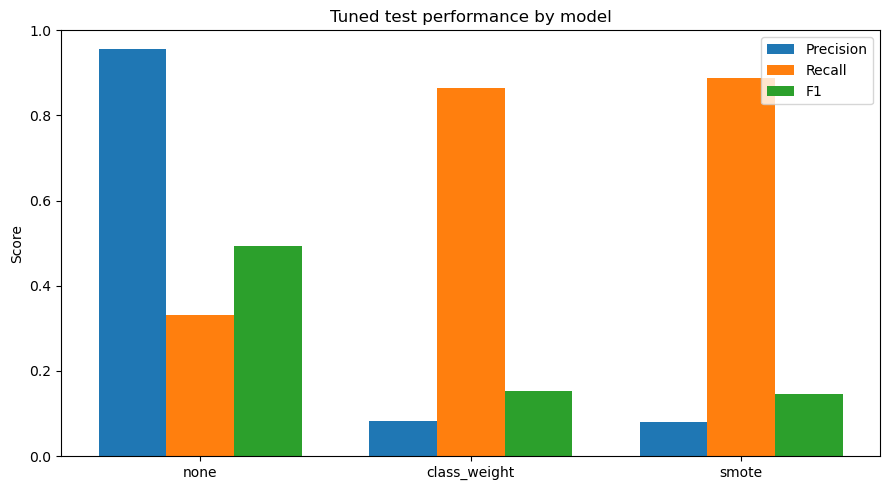

In [40]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    "tuned_test_precision",
    "tuned_test_recall",
    "tuned_test_f1"
]

metric_labels = [
    "Precision",
    "Recall",
    "F1"
]

x = np.arange(len(comparison_df["model"]))
width = 0.25

plt.figure(figsize=(9, 5))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        comparison_df[metric],
        width,
        label=metric_labels[i]
    )

plt.xticks(x + width, comparison_df["model"])
plt.ylabel("Score")
plt.title("Tuned test performance by model")
plt.legend()
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

This chart compares tuned precision, recall, and F1-score on the test set. The LR-none model has very high precision, which means that its fraud predictions are usually correct. However, its recall is low, so it misses many fraud cases.

The class-weighted and SMOTE models show the opposite pattern. Their precision is much lower, but their recall is much higher. This means that they detect many more fraud cases, although they also produce more false positives.

SMOTE has the highest recall, while LR-none has the highest F1-score. However, because fraud detection is cost-sensitive and false negatives are much more expensive than false positives, the higher recall of SMOTE is more valuable than the higher precision of LR-none.

## Expected cost comparison

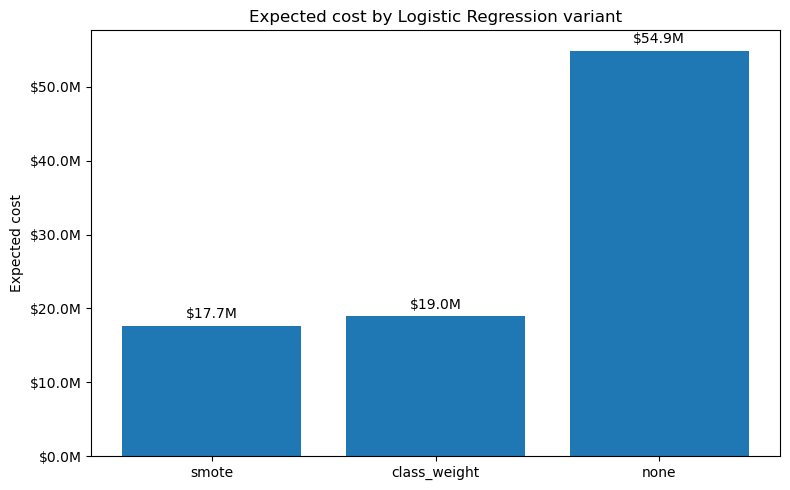

In [39]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

cost_plot_df = comparison_df.sort_values("tuned_expected_cost")

plt.figure(figsize=(8, 5))

bars = plt.bar(
    cost_plot_df["model"],
    cost_plot_df["tuned_expected_cost"]
)

plt.title("Expected cost by Logistic Regression variant")
plt.ylabel("Expected cost")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
)

plt.bar_label(
    bars,
    labels=[f"${v/1_000_000:.1f}M" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3
)

plt.tight_layout()
plt.show()

This chart compares the expected cost of the three Logistic Regression variants after threshold tuning. The LR-none model has the highest cost, at $54.9M, because it misses many fraud cases. The class-weighted and SMOTE models have much lower costs because they detect more fraud cases and reduce false negatives.

SMOTE achieves the lowest expected cost, $17.7M, followed by class weighting at $19.0M. This means that SMOTE is the best Logistic Regression variant from a cost-sensitive perspective. Although it produces more false positives than LR-none, it misses far fewer fraud cases, which is more important because false negatives are much more expensive in this experiment.

## Threshold performance plot

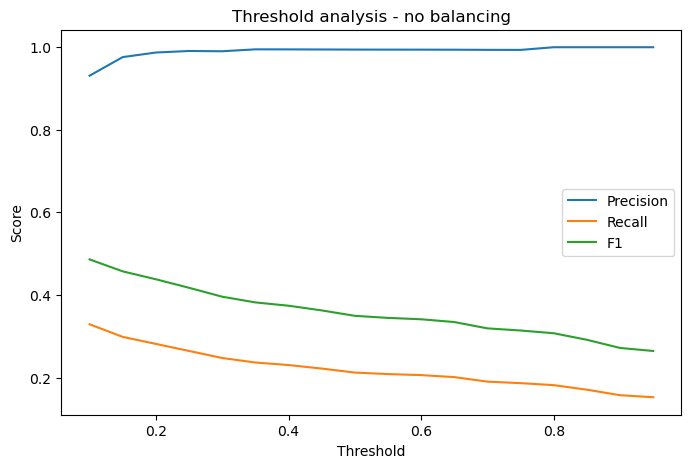

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_none["threshold"], threshold_results_none["precision"], label="Precision")
plt.plot(threshold_results_none["threshold"], threshold_results_none["recall"], label="Recall")
plt.plot(threshold_results_none["threshold"], threshold_results_none["f1"], label="F1")

plt.title("Threshold analysis - no balancing")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

This plot shows how precision, recall, and F1-score change when the threshold changes for the LR-none model.

At low thresholds, the model predicts fraud more often, so recall is higher. As the threshold increases, the model becomes more conservative and detects fewer fraud cases. Precision stays very high, but recall drops.

The highest F1-score is reached at the lowest tested threshold, 0.10. This supports the choice of 0.10 as the tuned threshold for LR-none. However, even at this threshold, recall is still limited, so the model still misses many fraud cases.

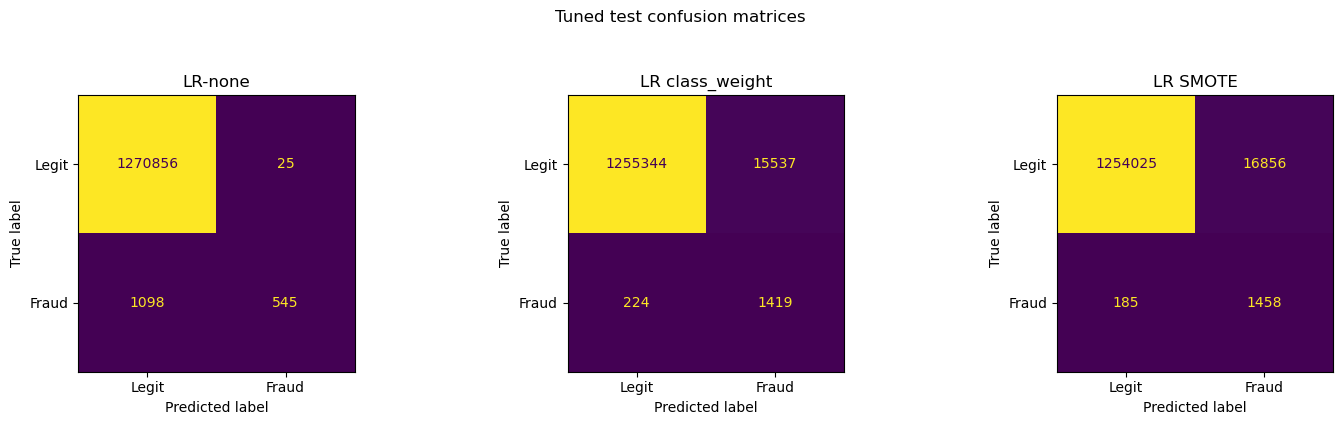

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm_list = [
    (tuned_cm_none, "LR-none"),
    (tuned_cm_weighted, "LR class_weight"),
    (tuned_cm_smote, "LR SMOTE"),
]

for ax, (cm, title) in zip(axes, cm_list):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legit", "Fraud"]
    )
    disp.plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(title)

plt.suptitle("Tuned test confusion matrices", y=1.05)
plt.tight_layout()
plt.show()

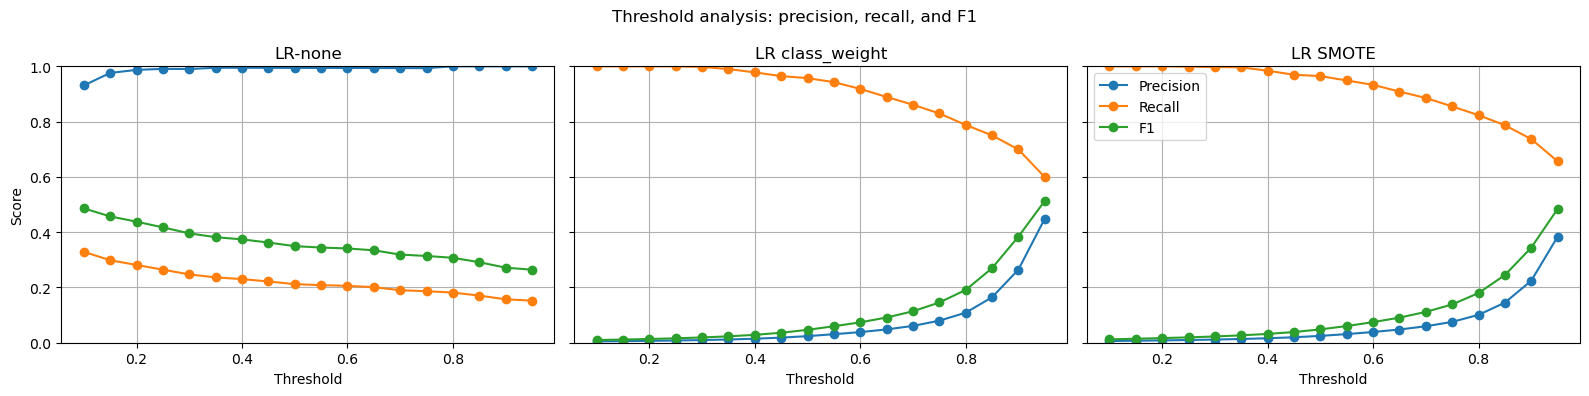

In [46]:
import matplotlib.pyplot as plt

threshold_tables = [
    (threshold_results_none, "LR-none"),
    (threshold_results_weighted, "LR class_weight"),
    (threshold_results_smote, "LR SMOTE"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (df, title) in zip(axes, threshold_tables):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"], marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"], marker="o", label="F1")
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylim(0, 1)
    ax.grid(True)

axes[0].set_ylabel("Score")
axes[-1].legend(loc="best")

plt.suptitle("Threshold analysis: precision, recall, and F1")
plt.tight_layout()
plt.show()

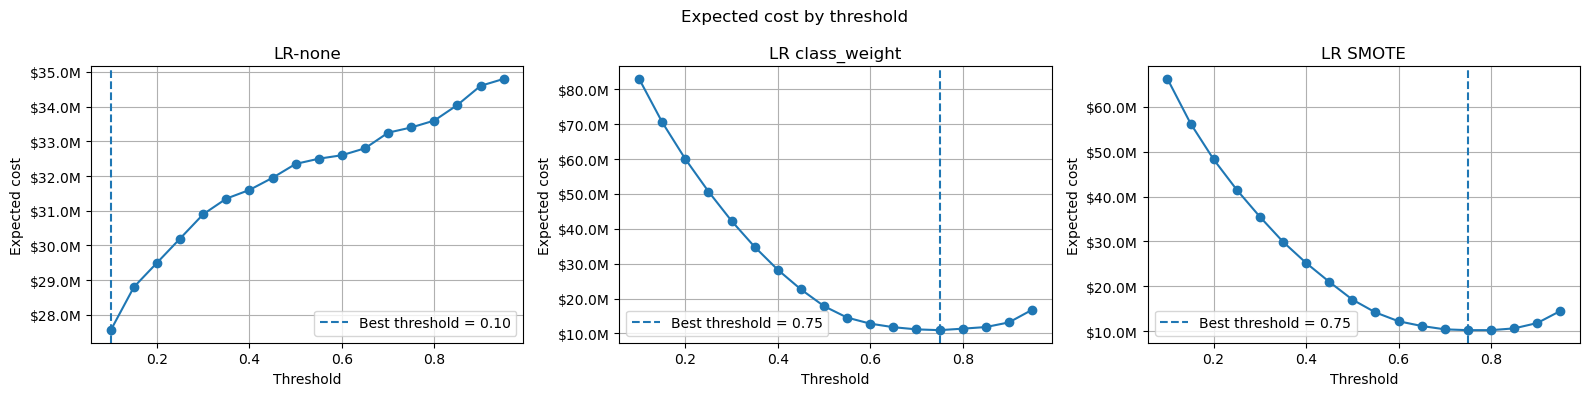

In [47]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

cost_tables = [
    (cost_df_none, "LR-none"),
    (cost_df_weighted, "LR class_weight"),
    (cost_df_smote, "LR SMOTE"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (df, title) in zip(axes, cost_tables):
    df_sorted = df.sort_values("threshold")
    best_row = df.loc[df["expected_cost"].idxmin()]
    
    ax.plot(
        df_sorted["threshold"],
        df_sorted["expected_cost"],
        marker="o"
    )
    
    ax.axvline(
        best_row["threshold"],
        linestyle="--",
        label=f"Best threshold = {best_row['threshold']:.2f}"
    )
    
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
    )
    ax.grid(True)
    ax.legend()

plt.suptitle("Expected cost by threshold")
plt.tight_layout()
plt.show()

## Precision-Recall curves

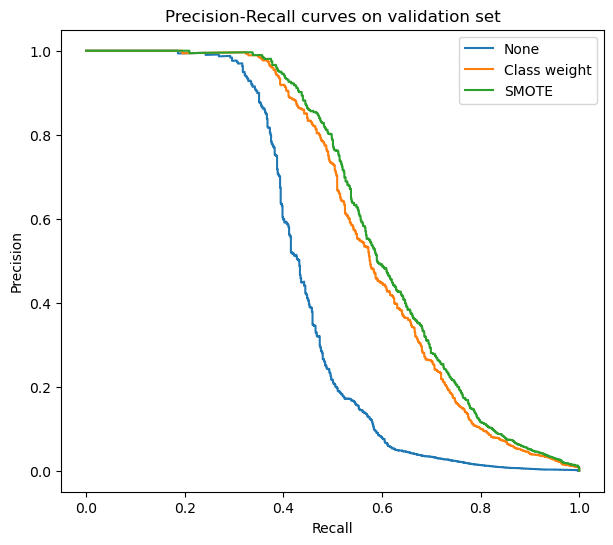

In [44]:
from sklearn.metrics import precision_recall_curve #all three model in one plot

scores_none = model_none.predict_proba(X_val)[:, 1]
scores_weighted = model_weighted.predict_proba(X_val)[:, 1]
scores_smote = model_smote.predict_proba(X_val)[:, 1]

p_none, r_none, _ = precision_recall_curve(y_val, scores_none)
p_weighted, r_weighted, _ = precision_recall_curve(y_val, scores_weighted)
p_smote, r_smote, _ = precision_recall_curve(y_val, scores_smote)

plt.figure(figsize=(7, 6))
plt.plot(r_none, p_none, label="None")
plt.plot(r_weighted, p_weighted, label="Class weight")
plt.plot(r_smote, p_smote, label="SMOTE")

plt.title("Precision-Recall curves on validation set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

The precision-recall curves show that the imbalance-aware models perform better than LR-none across most recall levels. LR-none loses precision quickly when recall increases, while class weighting and SMOTE maintain higher precision at higher recall. SMOTE is slightly stronger than class weighting, which matches its higher PR-AUC score. This confirms that SMOTE provides the best ranking performance among the Logistic Regression variants.

Three imbalance-handling strategies were compared for the full PaySim baseline: no balancing, class weighting, and SMOTE. Although the unbalanced model achieved the highest F1-score, it produced the highest expected cost because it missed too many fraudulent cases. Both class weighting and SMOTE substantially improved recall and reduced expected cost. Among them, SMOTE gave the best PR-AUC and the lowest expected cost, and was therefore selected as the final full tabular baseline.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

def plot_model_diagnostics_pretty(
    cm,
    threshold_results,
    cost_df,
    model_name,
    fn_cost=50_000,
    fp_cost=500,
    save_path=None
):
    cm = np.asarray(cm).astype(int)

    threshold_df = threshold_results.sort_values("threshold")
    cost_df_sorted = cost_df.sort_values("threshold")

    best_row = cost_df.loc[cost_df["expected_cost"].idxmin()]
    best_threshold = float(best_row["threshold"])
    best_validation_cost = float(best_row["expected_cost"])

    tn, fp, fn, tp = cm.ravel()
    test_expected_cost = fn * fn_cost + fp * fp_cost

    fig, axes = plt.subplots(
        1, 3,
        figsize=(17, 4.6),
        constrained_layout=True
    )

    fig.patch.set_facecolor("white")

    # --------------------------------------------------
    # 1. Tuned test confusion matrix
    # --------------------------------------------------
    ax = axes[0]

    cm_for_color = np.maximum(cm, 1)
    norm = LogNorm(vmin=1, vmax=cm_for_color.max())

    im = ax.imshow(
        cm_for_color,
        cmap="Blues",
        norm=norm
    )

    ax.set_title("Tuned test confusion matrix", fontsize=12, pad=12)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Legit", "Fraud"])
    ax.set_yticklabels(["Legit", "Fraud"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    for i in range(2):
        for j in range(2):
            value = cm[i, j]

            # Choose readable text color based on cell intensity
            rgba = im.cmap(norm(cm_for_color[i, j]))
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "white" if luminance < 0.45 else "#08306b"

            ax.text(
                j,
                i,
                f"{value:,}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=text_color
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    # --------------------------------------------------
    # 2. Validation metrics by threshold
    # --------------------------------------------------
    ax = axes[1]

    ax.plot(
        threshold_df["threshold"],
        threshold_df["precision"],
        linewidth=2.2,
        label="Precision"
    )
    ax.plot(
        threshold_df["threshold"],
        threshold_df["recall"],
        linewidth=2.2,
        label="Recall"
    )
    ax.plot(
        threshold_df["threshold"],
        threshold_df["f1"],
        linewidth=2.2,
        label="F1"
    )

    ax.axvline(
        best_threshold,
        linestyle="--",
        linewidth=1.8,
        color="black",
        alpha=0.7
    )

    ax.text(
        0.98,
        0.95,
        f"Best threshold = {best_threshold:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8)
    )

    ax.set_title("Validation metrics by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, loc="lower left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------------------------------------------------
    # 3. Validation expected cost by threshold
    # --------------------------------------------------
    ax = axes[2]

    ax.plot(
        cost_df_sorted["threshold"],
        cost_df_sorted["expected_cost"],
        linewidth=2.2,
        marker="o",
        markersize=4
    )

    ax.axvline(
        best_threshold,
        linestyle="--",
        linewidth=1.8,
        color="black",
        alpha=0.7
    )

    ax.scatter(
        best_threshold,
        best_validation_cost,
        s=80,
        color="black",
        zorder=5
    )

    ax.annotate(
        f"Min cost: ${best_validation_cost/1_000_000:.1f}M",
        xy=(best_threshold, best_validation_cost),
        xytext=(18, 18),
        textcoords="offset points",
        fontsize=10,
        arrowprops=dict(arrowstyle="->", linewidth=1, color="black"),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85)
    )

    ax.set_title("Validation expected cost by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Expected cost")
    ax.grid(True, alpha=0.25)

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M")
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"{model_name} diagnostics | Tuned test cost",
        fontsize=15,
        fontweight="bold"
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

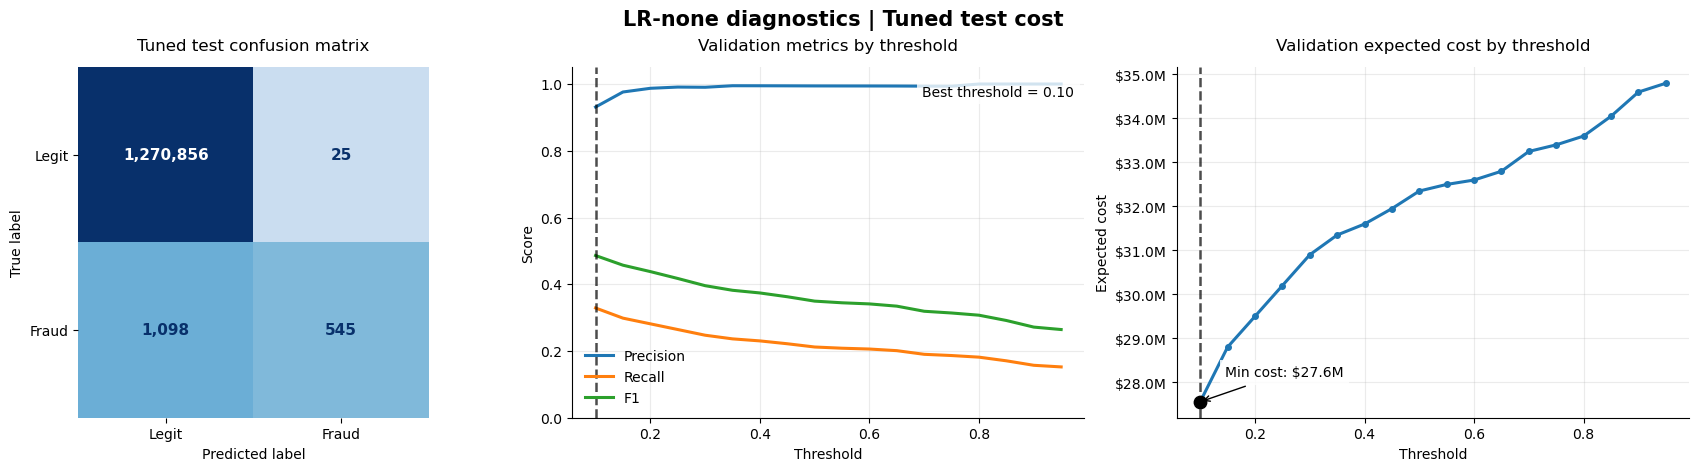

In [62]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_none,
    threshold_results=threshold_results_none,
    cost_df=cost_df_none,
    model_name="LR-none"
)

The confusion matrix shows the final test performance at the selected threshold. The model produces very few false positives, but it still misses many fraud cases.

The threshold plot shows that LR-none is conservative: precision stays very high across thresholds, while recall remains low and decreases as the threshold increases. The cost curve shows that the lowest validation cost is reached at threshold 0.10, which is why this threshold was selected.

Overall, lowering the threshold improves the LR-none model, but it still misses too much fraud.

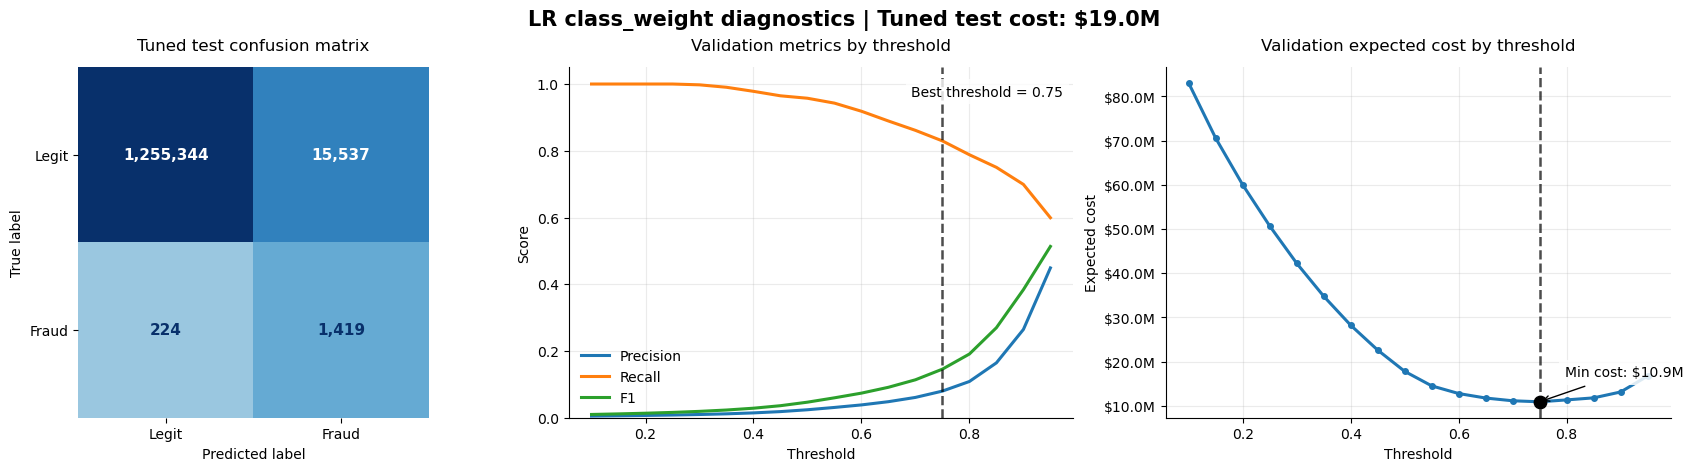

In [60]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_weighted,
    threshold_results=threshold_results_weighted,
    cost_df=cost_df_weighted,
    model_name="LR class_weight"
)

Unlike LR-none, this model is much more sensitive to fraud. At the selected threshold of 0.75, it detects 1,419 fraud cases and misses only 224.

The threshold plot shows that recall stays high across most thresholds, while precision increases as the threshold becomes higher. This means that increasing the threshold helps reduce false positives. The cost curve shows that the lowest validation cost is reached at threshold 0.75, which is why this threshold was selected.

Overall, class weighting greatly improves recall compared with LR-none, but it still produces many false positives.

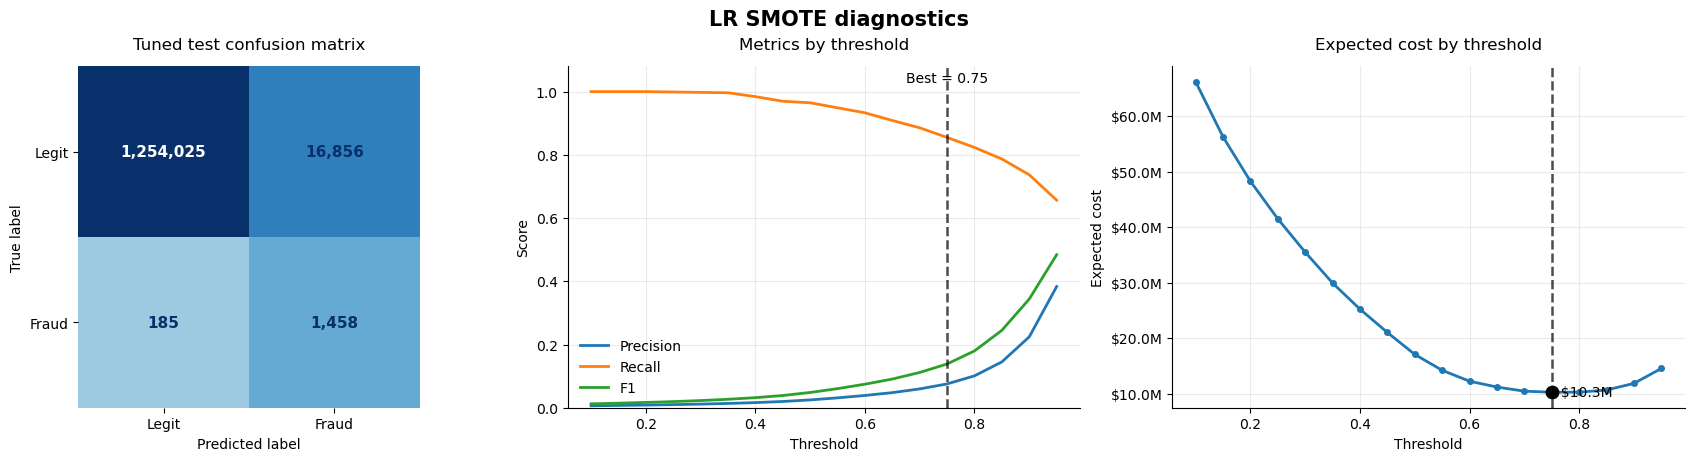

In [57]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_smote,
    threshold_results=threshold_results_smote,
    cost_df=cost_df_smote,
    model_name="LR SMOTE"
)

 At the selected threshold of 0.75, the model detects 1,458 fraud cases and misses only 185. This is the lowest number of missed fraud cases among the three Logistic Regression variants.

The threshold plot shows that recall stays high across most thresholds, while precision improves as the threshold increases. The cost curve shows that the lowest validation cost is reached at threshold 0.75, which explains why this threshold was selected.

Overall, SMOTE gives the best cost-sensitive result. It detects the most fraud cases and achieves the lowest expected cost, although it still produces many false positives.

## Final choice

Although the no-balance model had the highest tuned F1-score, it missed too many fraud cases and resulted in the highest expected cost. SMOTE achieved the best overall fraud-focused performance, especially in terms of PR-AUC and expected cost, and was therefore selected as the final full tabular baseline.

In [49]:
final_choice_df = comparison_df.sort_values("tuned_expected_cost").copy()
final_choice_df

,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
2,smote,0.048229,0.993306,0.619049,0.048965,0.994149,0.619863,0.75,0.079611,0.887401,0.146114,17678000
1,class_weight,0.046614,0.991780,0.599905,0.047195,0.992945,0.601748,0.75,0.083687,0.863664,0.152589,18968500
0,none,0.349398,0.946992,0.449465,0.356000,0.952047,0.454219,0.10,0.956140,0.331710,0.492544,54912500
